In [1626]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%store -r df

# Badanie Df

### Wyświetlijmy najpierw wszystkie wiersze w "df"

In [1627]:
df

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
A.j. English,HydroTruck Radom,7,233:16,33:19,153,21.86,47.0,6.7,99.0,14.1,...,7,1.00,2,0.29,3,0.43,18,2.57,36,5.14
William Garrett,Grupa Sierleccy Czarni Słupsk,7,243:15,34:45,142,20.29,46.0,6.6,106.0,15.1,...,11,1.57,2,0.29,4,0.57,15,2.14,42,6.00
Jabarie Hinds,GTK Gliwice,7,233:02,33:17,137,19.57,47.0,6.7,95.0,13.6,...,7,1.00,2,0.29,7,1.00,7,1.00,31,4.43
Stacy Davis,King Szczecin,7,228:15,32:36,127,18.14,48.0,6.9,99.0,14.1,...,7,1.00,7,1.00,8,1.14,12,1.71,20,2.86
Michael Moore,HydroTruck Radom,8,261:07,32:38,126,15.75,47.0,5.9,106.0,13.3,...,11,1.38,3,0.38,6,0.75,22,2.75,22,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Błażej Kulikowski,Grupa Sierleccy Czarni Słupsk,6,29:43,04:57,1,0.17,0.0,0.0,0.0,0.0,...,0,0.00,0,0.00,0,0.00,4,0.67,1,0.17
Rafał Komenda,Anwil Włocławek,4,04:02,01:01,0,0.00,0.0,0.0,0.0,0.0,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.00
Szymon Kołakowski,Legia Warszawa,4,07:59,02:00,0,0.00,0.0,0.0,0.0,0.0,...,1,0.25,0,0.00,0,0.00,2,0.50,0,0.00


# Typy danych występujących w df

In [1628]:
df.select_dtypes(include="number")

,Mecze,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,Skuteczność z gry,Celne rzuty za 2 suma,Celne rzuty za 2 śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
A.j. English,7,153,21.86,47.0,6.7,99.0,14.1,47.5,21.0,3.0,...,7,1.00,2,0.29,3,0.43,18,2.57,36,5.14
William Garrett,7,142,20.29,46.0,6.6,106.0,15.1,43.4,39.0,5.6,...,11,1.57,2,0.29,4,0.57,15,2.14,42,6.00
Jabarie Hinds,7,137,19.57,47.0,6.7,95.0,13.6,49.5,34.0,4.9,...,7,1.00,2,0.29,7,1.00,7,1.00,31,4.43
Stacy Davis,7,127,18.14,48.0,6.9,99.0,14.1,48.5,39.0,5.6,...,7,1.00,7,1.00,8,1.14,12,1.71,20,2.86
Michael Moore,8,126,15.75,47.0,5.9,106.0,13.3,44.3,34.0,4.3,...,11,1.38,3,0.38,6,0.75,22,2.75,22,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Błażej Kulikowski,6,1,0.17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.00,0,0.00,0,0.00,4,0.67,1,0.17
Rafał Komenda,4,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.00,0,0.00,0,0.00,0,0.00,0,0.00
Szymon Kołakowski,4,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0.25,0,0.00,0,0.00,2,0.50,0,0.00


### Wszystkie dane będące typem "object"

In [1629]:
df.select_dtypes(include="object")

,Drużyna,Czas gry suma,Czas gry śr.
Zawodnik,,,
A.j. English,HydroTruck Radom,233:16,33:19
William Garrett,Grupa Sierleccy Czarni Słupsk,243:15,34:45
Jabarie Hinds,GTK Gliwice,233:02,33:17
Stacy Davis,King Szczecin,228:15,32:36
Michael Moore,HydroTruck Radom,261:07,32:38
...,...,...,...
Błażej Kulikowski,Grupa Sierleccy Czarni Słupsk,29:43,04:57
Rafał Komenda,Anwil Włocławek,04:02,01:01
Szymon Kołakowski,Legia Warszawa,07:59,02:00


# Najlepsi zawodnicy pod względem zdobywania punktów, asyst, zbiórek oraz bloków

## Punkty

### Zawodnik, który zdobył najwięcej punktów łącznie.

In [1630]:
df[df["Punkty suma"] == df["Punkty suma"].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
A.j. English,HydroTruck Radom,7,233:16,33:19,153,21.86,47.0,6.7,99.0,14.1,...,7,1.0,2,0.29,3,0.43,18,2.57,36,5.14


In [1631]:
df.loc["A.j. English"]["Punkty suma"]

153

### Zawodnik, który ma największą średnią punktów na mecz.

In [1632]:
df[df["Punkty śr."] == df["Punkty śr."].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
A.j. English,HydroTruck Radom,7,233:16,33:19,153,21.86,47.0,6.7,99.0,14.1,...,7,1.0,2,0.29,3,0.43,18,2.57,36,5.14


In [1633]:
df.loc["A.j. English"]["Punkty śr."]

21.86

## Asysty

### Zawodnik, który zdobył najwięcej asyst łącznie.

In [1634]:
df[df["Asysty suma"] == df["Asysty suma"].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Maurice Watson,Twarde Pierniki Toruń,7,237:39,33:57,116,16.57,46.0,6.6,99.0,14.1,...,13,1.86,0,0.0,5,0.71,18,2.57,33,4.71


In [1635]:
df.loc["Maurice Watson"]["Asysty suma"]

71

### Zawodnik, który ma największą średnią asyst na mecz.

In [1636]:
df[df["Asysty śr."] == df["Asysty śr."].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Maurice Watson,Twarde Pierniki Toruń,7,237:39,33:57,116,16.57,46.0,6.6,99.0,14.1,...,13,1.86,0,0.0,5,0.71,18,2.57,33,4.71


In [1637]:
df.loc["Maurice Watson"]["Asysty śr."]

10.1

## Zbiórki

### Zawodnik, który zdobył najwięcej zbiórek łącznie.

In [1638]:
df[df["Zbiórki suma"] == df["Zbiórki suma"].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Klavs Čavars,Enea Abramczyk Astoria Bydgoszcz,7,194:36,27:48,78,11.14,32.0,4.6,58.0,8.3,...,3,0.43,13,1.86,4,0.57,15,2.14,18,2.57


In [1639]:
df.loc["Klavs Čavars"]["Zbiórki suma"]

63

### Zawodnik, który ma największą średnią zbiórek na mecz.

In [1640]:
df[df["Zbiórki śr"] == df["Zbiórki śr"].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Klavs Čavars,Enea Abramczyk Astoria Bydgoszcz,7,194:36,27:48,78,11.14,32.0,4.6,58.0,8.3,...,3,0.43,13,1.86,4,0.57,15,2.14,18,2.57


In [1641]:
df.loc["Klavs Čavars"]["Zbiórki śr"]

9.0

## Bloki

### Zawodnik, który zdobył najwięcej bloków łącznie.

In [1642]:
df[df["Bloki suma"] == df["Bloki suma"].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Joshua Sharma,Trefl Sopot,7,157:37,22:31,95,13.57,37.0,5.3,57.0,8.1,...,5,0.71,21,3.0,3,0.43,27,3.86,16,2.29


In [1643]:
df.loc["Joshua Sharma"]["Bloki suma"]

21

### Zawodnik, który ma największą średnią bloków na mecz.

In [1644]:
df[df["Bloki śr"] == df["Bloki śr"].max()]

,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Joshua Sharma,Trefl Sopot,7,157:37,22:31,95,13.57,37.0,5.3,57.0,8.1,...,5,0.71,21,3.0,3,0.43,27,3.86,16,2.29


In [1645]:
df.loc["Joshua Sharma"]["Bloki śr"]

3.0

# Przyjrzyjmy się wynikom zawodnika, który głosem trenerów został wybrany najlepszym defensywnym graczem osatniego sezonu, Ivan Ramljak.

In [1646]:
Ivan_Ramljak = df.loc["Ivan Ramljak"]

## Podstawowe informacje

In [1647]:
info_Ivan_Ramljak = pd.Series(
    [Ivan_Ramljak["Drużyna"],Ivan_Ramljak["Mecze"],Ivan_Ramljak["Czas gry suma"],Ivan_Ramljak["Czas gry śr."]], 
    index=["Drużyna","Mecze","Czas gry suma","Czas gry śr."]
)
info_Ivan_Ramljak

Drużyna          WKS Śląsk Wrocław 
Mecze                             6
Czas gry suma                175:00
Czas gry śr.                  29:10
dtype: object

## Statystyki odnośnie zbiórek

In [1648]:
zbiorki_Ivan_Ramljak = pd.Series(
    [Ivan_Ramljak["Zbiórki w ataku suma"],Ivan_Ramljak["Zbiórki w ataku śr."],Ivan_Ramljak["Zbiórki w obronie suma"],Ivan_Ramljak["Zbiórki w obronie śr."],Ivan_Ramljak["Zbiórki suma"],Ivan_Ramljak["Zbiórki śr"]],
    index=["Zbiórki w ataku suma","Zbiórki w ataku śr.","Zbiórki w obronie suma","Zbiórki w obronie śr.","Zbiórki suma","Zbiórki śr"]
)
zbiorki_Ivan_Ramljak

Zbiórki w ataku suma      10.00
Zbiórki w ataku śr.        1.70
Zbiórki w obronie suma    27.00
Zbiórki w obronie śr.      4.50
Zbiórki suma              37.00
Zbiórki śr                 6.17
dtype: float64

## Statystyki odnośnie przechwyt

In [1649]:
przechwyty_Ivan_Ramljak = pd.Series(
    [Ivan_Ramljak["Przechwyty suma"],Ivan_Ramljak["Przechwyty śr"]],
    index=["Przechwyty suma","Przechwyty śr"]
)
przechwyty_Ivan_Ramljak

Przechwyty suma    7.00
Przechwyty śr      1.17
dtype: float64

## Statystyki odnośnie bloków

In [1650]:
bloki_Ivan_Ramljak = pd.Series(
    [Ivan_Ramljak["Bloki suma"],Ivan_Ramljak["Bloki śr"]],
    index=["Bloki suma","Bloki śr"]
)
bloki_Ivan_Ramljak

Bloki suma    3.0
Bloki śr      0.5
dtype: float64

# Którzy zawodnicy zdobywają średnio więcej niż 20pkt na mecz

In [1651]:
df[df["Punkty śr."] > 20].index

Index(['A.j. English', 'William Garrett'], dtype='object', name='Zawodnik')

# Zawodnik z największą skutecznością za 3

In [1652]:
df[df['Skuteczność za 3'] == df['Skuteczność za 3'].max()].index

Index(['Michael Young'], dtype='object', name='Zawodnik')

# Osoba, która zagrała więcej niż 5 meczy z największą ilością fauli

In [1653]:
zawodnik_faul = df[(df["Mecze"]>5) & (df["Faule wymuszone suma"] == df["Faule wymuszone suma"].max())]
zawodnik_faul


,Drużyna,Mecze,Czas gry suma,Czas gry śr.,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Zawodnik,,,,,,,,,,,,,,,,,,,,,
Dragan Apić,Enea Zastal BC Zielona Góra,7,192:43,27:32,119,17.0,48.0,6.9,77.0,11.0,...,8,1.14,4,0.57,4,0.57,26,3.71,44,6.29


# Histogramy

## Skuteczność za 2 przez każdą z drużyn 

In [1654]:
druzyna_rzuty_2 = df[["Drużyna","Skuteczność za 2"]]

In [1655]:
druzyny = list(df["Drużyna"].unique())
druzyny

['HydroTruck Radom ',
 'Grupa Sierleccy Czarni Słupsk ',
 'GTK Gliwice ',
 'King Szczecin ',
 'Anwil Włocławek ',
 'MKS Dąbrowa Górnicza ',
 'Enea Zastal BC Zielona Góra ',
 'Polski Cukier Pszczółka Start Lublin ',
 'Trefl Sopot ',
 'Twarde Pierniki Toruń ',
 'Legia Warszawa ',
 'PGE Spójnia Stargard ',
 'Arged BM Stal Ostrów Wlkp. ',
 'WKS Śląsk Wrocław ',
 'Asseco Arka Gdynia ',
 'Enea Abramczyk Astoria Bydgoszcz ',
 'Asseco Arka Gdynia']

## Zmieniamy nazwy drużyn na nazwy miasty, aby zmieścić nazwy na wykresach

In [1656]:
druzyna_rzuty_2["Drużyna"] = druzyna_rzuty_2.replace({
'HydroTruck Radom ':"Radom",
'Grupa Sierleccy Czarni Słupsk ': "Słupsk",
'GTK Gliwice ':"Gliwice",
'King Szczecin ':"Szczecin",
 'Anwil Włocławek ':"Wrocławek",
 'MKS Dąbrowa Górnicza ':"Dąbrowa Górnicza",
 'Enea Zastal BC Zielona Góra ': 'Zielona Góra',
 'Polski Cukier Pszczółka Start Lublin ':'Lublin',
 'Trefl Sopot ':'Sopot',
 'Twarde Pierniki Toruń ':'Toruń',
 'Legia Warszawa ':'Warszawa',
 'PGE Spójnia Stargard ':'Stargard',
 'Arged BM Stal Ostrów Wlkp. ':'Ostrów Wlkp.',
 'WKS Śląsk Wrocław ':'Wrocław',
 'Asseco Arka Gdynia ': 'Gdynia',
 'Enea Abramczyk Astoria Bydgoszcz ' :"Bydgoszcz",
 })

<ipython-input-1656-3a4fad0e8fb3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  druzyna_rzuty_2["Drużyna"] = druzyna_rzuty_2.replace({


In [1657]:
druzyna_rzuty_2

,Drużyna,Skuteczność za 2
Zawodnik,,
A.j. English,Radom,52.5
William Garrett,Słupsk,50.0
Jabarie Hinds,Gliwice,49.3
Stacy Davis,Szczecin,52.7
Michael Moore,Radom,53.1
...,...,...
Błażej Kulikowski,Słupsk,0.0
Rafał Komenda,Wrocławek,0.0
Szymon Kołakowski,Warszawa,0.0


array([[<AxesSubplot:title={'center':'Asseco Arka Gdynia'}>,
        <AxesSubplot:title={'center':'Bydgoszcz'}>,
        <AxesSubplot:title={'center':'Dąbrowa Górnicza'}>,
        <AxesSubplot:title={'center':'Gdynia'}>],
       [<AxesSubplot:title={'center':'Gliwice'}>,
        <AxesSubplot:title={'center':'Lublin'}>,
        <AxesSubplot:title={'center':'Ostrów Wlkp.'}>,
        <AxesSubplot:title={'center':'Radom'}>],
       [<AxesSubplot:title={'center':'Sopot'}>,
        <AxesSubplot:title={'center':'Stargard'}>,
        <AxesSubplot:title={'center':'Szczecin'}>,
        <AxesSubplot:title={'center':'Słupsk'}>],
       [<AxesSubplot:title={'center':'Toruń'}>,
        <AxesSubplot:title={'center':'Warszawa'}>,
        <AxesSubplot:title={'center':'Wrocław'}>,
        <AxesSubplot:title={'center':'Wrocławek'}>],
       [<AxesSubplot:title={'center':'Zielona Góra'}>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], dtype=object)

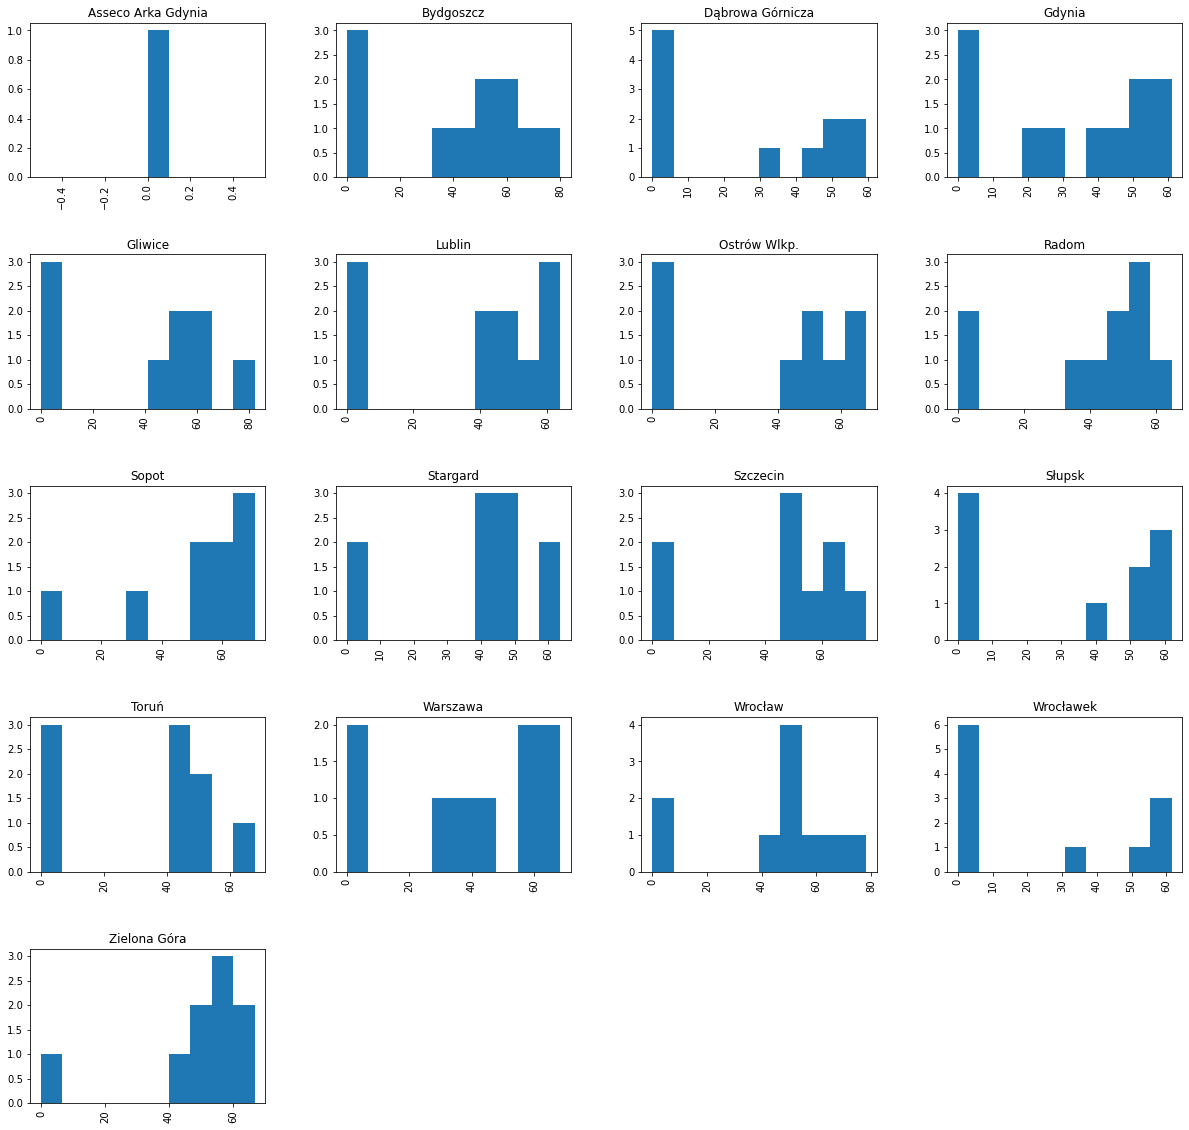

In [1658]:
druzyna_rzuty_2.hist(by=druzyna_rzuty_2["Drużyna"], figsize=(20,20))

# Box wykres

<AxesSubplot:xlabel='Drużyna', ylabel='Skuteczność za 2'>

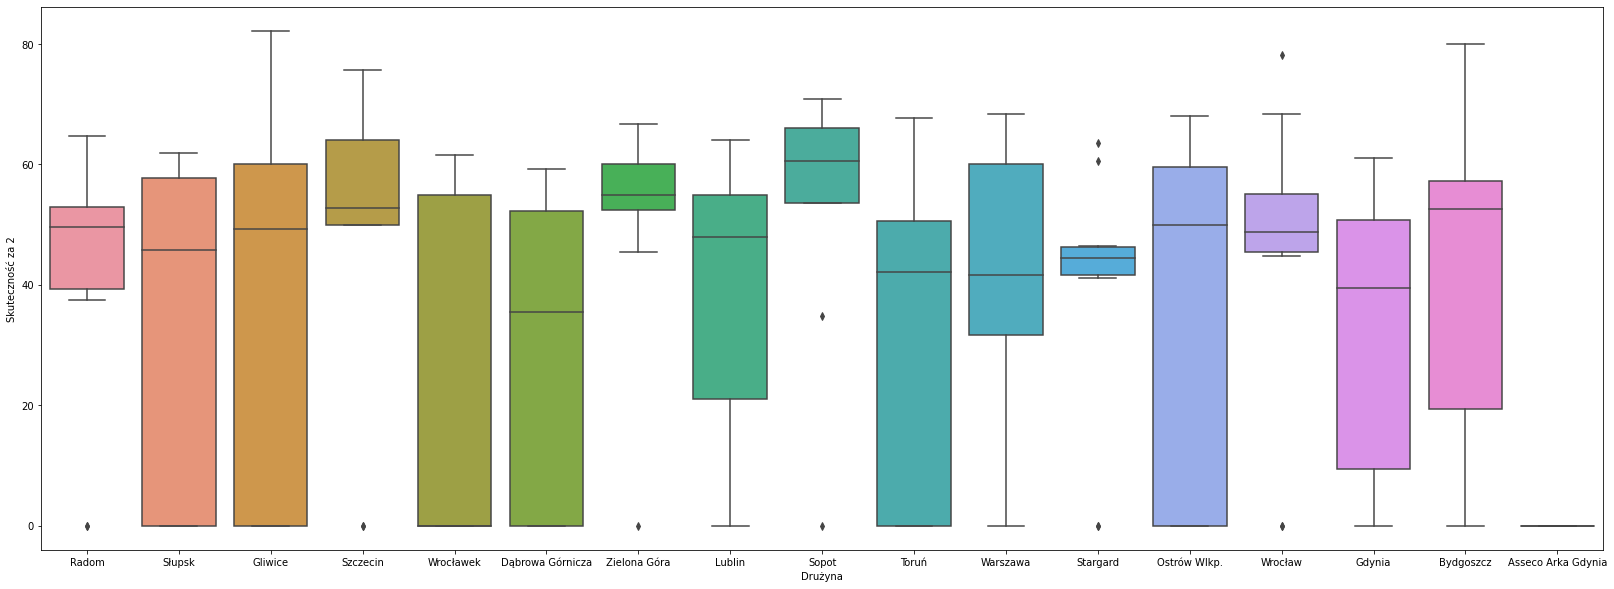

In [1659]:
plt.figure(figsize=(28,10))
sns.boxplot(x = 'Drużyna', y = 'Skuteczność za 2', data = druzyna_rzuty_2)

# Heat map

In [1660]:
corr = df.corr()
corr


,Mecze,Punkty suma,Punkty śr.,Celne rzuty z gry suma,Celne rzuty z gry śr.,Oddane rzuty z gry suma,Oddane rzuty z gry śr.,Skuteczność z gry,Celne rzuty za 2 suma,Celne rzuty za 2 śr.,...,Przechwyty suma,Przechwyty śr,Bloki suma,Bloki śr,Bloki otrzymane suma,Bloki otrzymane śr,Faule suma,Faule śr.,Faule wymuszone suma,Faule wymuszone śr.
Mecze,1.000000,0.492171,0.329083,0.498110,0.354649,0.471309,0.288226,0.411301,0.459332,0.374099,...,0.359088,0.187403,0.213280,0.174266,0.256374,0.071935,0.528996,0.205817,0.440592,0.278825
Punkty suma,0.492171,1.000000,0.974867,0.981020,0.956784,0.960742,0.913365,0.624713,0.839608,0.822350,...,0.598005,0.536982,0.246943,0.221289,0.493583,0.403772,0.541697,0.425156,0.824181,0.785664
Punkty śr.,0.329083,0.974867,1.000000,0.953546,0.975968,0.941446,0.948255,0.625463,0.803438,0.816588,...,0.578417,0.560802,0.213156,0.196310,0.482583,0.438942,0.491679,0.445821,0.795615,0.801470
Celne rzuty z gry suma,0.498110,0.981020,0.953546,1.000000,0.977169,0.957263,0.911064,0.694246,0.895295,0.878393,...,0.597182,0.536588,0.279624,0.251291,0.503313,0.413426,0.551635,0.431261,0.796851,0.756484
Celne rzuty z gry śr.,0.354649,0.956784,0.975968,0.977169,1.000000,0.941451,0.947308,0.708336,0.864517,0.877640,...,0.582910,0.563583,0.248120,0.227491,0.496202,0.450232,0.506586,0.448978,0.770527,0.771276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Bloki otrzymane śr,0.071935,0.403772,0.438942,0.413426,0.450232,0.430414,0.474922,0.280094,0.469551,0.505419,...,0.193232,0.210089,0.113964,0.105472,0.960096,1.000000,0.170377,0.183078,0.416141,0.455576
Faule suma,0.528996,0.541697,0.491679,0.551635,0.506586,0.527754,0.463195,0.605996,0.477893,0.448402,...,0.415949,0.355631,0.299705,0.282396,0.255622,0.170377,1.000000,0.925533,0.536419,0.485072
Faule śr.,0.205817,0.425156,0.445821,0.431261,0.448978,0.419165,0.432630,0.548697,0.355421,0.361935,...,0.344778,0.360574,0.246410,0.245667,0.197696,0.183078,0.925533,1.000000,0.436458,0.453983
Faule wymuszone suma,0.440592,0.824181,0.795615,0.796851,0.770527,0.775954,0.728850,0.546761,0.782626,0.768397,...,0.542651,0.487405,0.215179,0.193753,0.492659,0.416141,0.536419,0.436458,1.000000,0.976861


<AxesSubplot:>

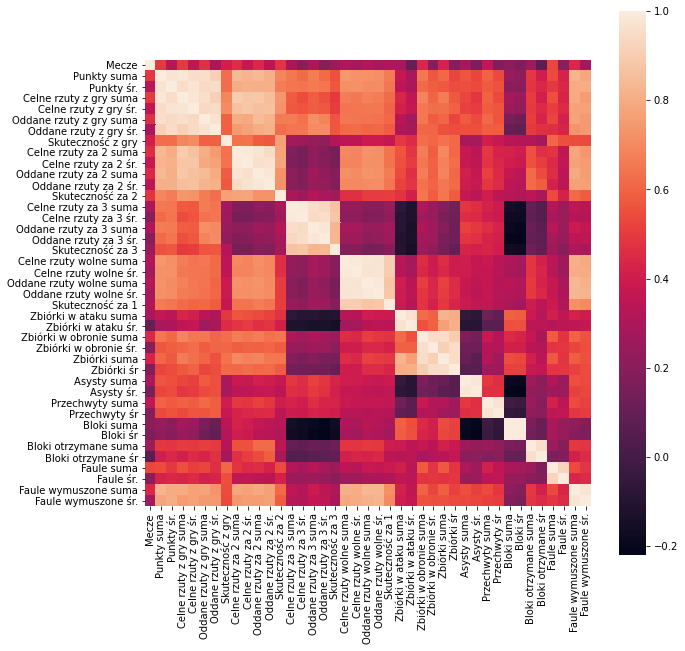

In [1625]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corr, square=True)